In [61]:
!pip install givernylocal

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from givernylocal.turbulence_dataset import turb_dataset
from givernylocal.turbulence_toolkit import getCutout

In [63]:
cube = turb_dataset(
    dataset_title="isotropic1024coarse",
    output_path="./jhtdb_output",
    auth_token="edu.jhu.pha.turbulence.testing-201406"
)

In [64]:
axes_ranges = np.array([
    [1,16],   # x
    [1,16],   # y
    [1,16],   # z
    [1,1]     # time
])

strides = np.array([1,1,1,1])

cutout = getCutout(
    cube,
    var="velocity",
    xyzt_axes_ranges_original=axes_ranges,
    xyzt_strides=strides
)


-----
getCutout is processing...

total time elapsed = 0.362 seconds (0.006 minutes)

query completed successfully.
-----


In [65]:
print(cutout)

<xarray.Dataset> Size: 50kB
Dimensions:        (zcoor: 16, ycoor: 16, xcoor: 16, values: 3)
Coordinates:
  * zcoor          (zcoor) float64 128B 0.0 0.006136 0.01227 ... 0.0859 0.09204
  * ycoor          (ycoor) float64 128B 0.0 0.006136 0.01227 ... 0.0859 0.09204
  * xcoor          (xcoor) float64 128B 0.0 0.006136 0.01227 ... 0.0859 0.09204
Dimensions without coordinates: values
Data variables:
    velocity_0001  (zcoor, ycoor, xcoor, values) float32 49kB -0.6635 ... -0....
Attributes: (12/14)
    dataset:      isotropic1024coarse
    t_start:      1
    t_end:        1
    t_step:       1
    x_start:      1
    y_start:      1
    ...           ...
    y_end:        16
    z_end:        16
    x_step:       1
    y_step:       1
    z_step:       1
    filterWidth:  1


In [66]:
velocity = cutout["velocity_0001"].values

print(velocity.shape)

(16, 16, 16, 3)


In [67]:
speed = np.sqrt(
    velocity[:,:,:,0]**2 +
    velocity[:,:,:,1]**2 +
    velocity[:,:,:,2]**2
)

print(speed.shape)

(16, 16, 16)


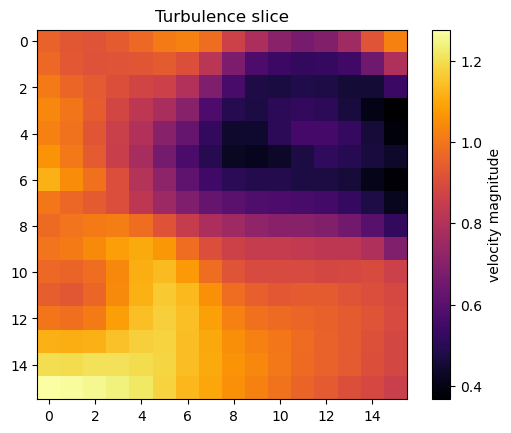

In [68]:
plt.imshow(speed[:,:,8], cmap="inferno")
plt.colorbar(label="velocity magnitude")
plt.title("Turbulence slice")
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_11232\1913285868.py:20: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


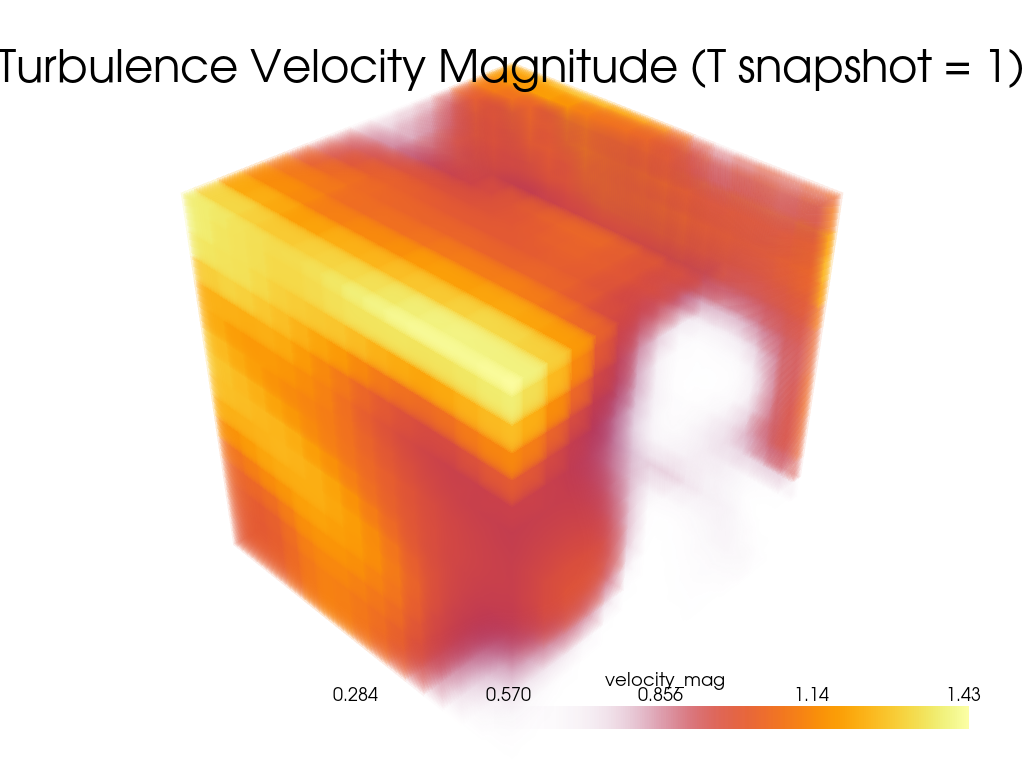

In [ ]:
import pyvista as pv

grid = pv.ImageData()

grid.dimensions = np.array(speed.shape) + 1
grid.spacing = (1,1,1)
grid.origin = (0,0,0)

grid.cell_data["velocity_mag"] = speed.flatten(order="F")

plotter = pv.Plotter()

plotter.add_volume(
    grid,
    cmap="inferno",
    opacity="sigmoid"
)

plotter.add_title("Turbulence Velocity Magnitude (velocity_0001)")
plotter.show()

Filtered shape: (16, 16, 16)
Downsampled shape: (8, 8, 8)


C:\Users\ACER\AppData\Local\Temp\ipykernel_11232\2188242271.py:35: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


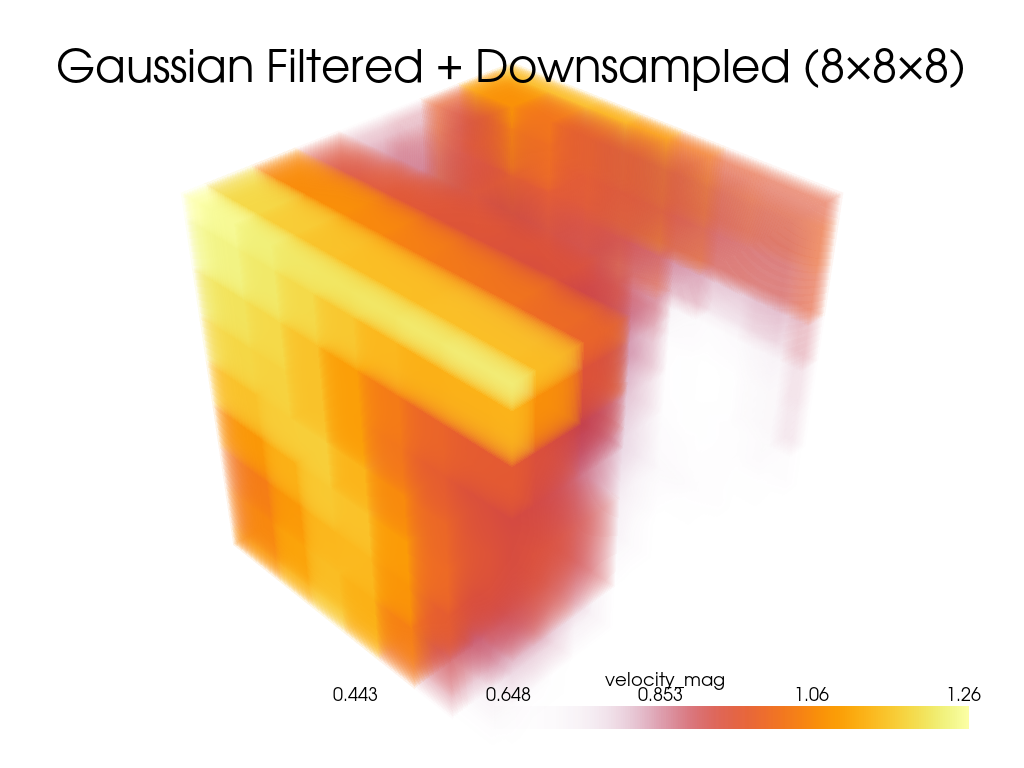

In [70]:
from scipy.ndimage import gaussian_filter

# ---- 1. Gaussian filter ----
sigma = 1.0   # smoothing strength

speed_filtered = gaussian_filter(speed, sigma=sigma)

print("Filtered shape:", speed_filtered.shape)


# ---- 2. Downsample (16³ -> 8³) ----
speed_down = speed_filtered[::2, ::2, ::2]

print("Downsampled shape:", speed_down.shape)


# ---- 3. Visualize coarse volume ----
grid2 = pv.ImageData()

grid2.dimensions = np.array(speed_down.shape) + 1
grid2.spacing = (1,1,1)
grid2.origin = (0,0,0)

grid2.cell_data["velocity_mag"] = speed_down.flatten(order="F")

plotter = pv.Plotter()

plotter.add_volume(
    grid2,
    cmap="inferno",
    opacity="sigmoid"
)

plotter.add_title("Gaussian Filtered + Downsampled (8×8×8)")
plotter.show()